<a href="https://colab.research.google.com/github/elias8080007/OIBSIP/blob/main/DataAnalytics-L2-FraudDetection/Elias_Ibrahim_Elias_Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection

**Oasis Infobyte Data Analytics Internship — Level 2, Task 3**

**Author:** Elias Ibrahim Elias  
**Track:** Data Analytics  
**Tools:** Python, pandas, scikit-learn, matplotlib, seaborn and Google Colab

## Project Objective

The objective of this project is to build and evaluate a machine learning pipeline capable of detecting fraudulent credit card transactions in a highly imbalanced dataset.

The analysis focuses on transaction patterns, class imbalance, appropriate evaluation metrics, and the trade-off between detecting fraudulent transactions and avoiding unnecessary false alarms.

In [1]:
!pip -q install kagglehub

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Download the Credit Card Fraud Detection dataset
dataset_directory = kagglehub.dataset_download(
    "mlg-ulb/creditcardfraud"
)

csv_path = Path(dataset_directory) / "creditcard.csv"

# Load the dataset
df = pd.read_csv(csv_path)

print(f"Dataset location: {csv_path}")
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

display(df.head())

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dataset location: /kaggle/input/creditcardfraud/creditcard.csv
Number of rows: 284,807
Number of columns: 31


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


## 1. Data Quality Assessment

Before performing exploratory analysis or modelling, the dataset is checked for missing values, duplicate records, incorrect target labels, infinite values, and impossible transaction values.

In [3]:
# Create a compact data-quality report
quality_report = pd.DataFrame({
    "Data_Type": df.dtypes.astype(str),
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (df.isna().mean() * 100).round(4),
    "Unique_Values": df.nunique()
})

duplicate_count = df.duplicated().sum()
infinite_count = np.isinf(
    df.select_dtypes(include=np.number)
).sum().sum()

invalid_class_count = (~df["Class"].isin([0, 1])).sum()
negative_amount_count = (df["Amount"] < 0).sum()
negative_time_count = (df["Time"] < 0).sum()

display(quality_report)

print("Additional quality checks:")
print(f"Duplicate rows: {duplicate_count:,}")
print(f"Infinite numerical values: {infinite_count:,}")
print(f"Invalid target labels: {invalid_class_count:,}")
print(f"Negative transaction amounts: {negative_amount_count:,}")
print(f"Negative transaction times: {negative_time_count:,}")

,Data_Type,Missing_Count,Missing_Percentage,Unique_Values
Time,float64,0,0.0000,124592
V1,float64,0,0.0000,275663
V2,float64,0,0.0000,275663
V3,float64,0,0.0000,275663
V4,float64,0,0.0000,275663
V5,float64,0,0.0000,275663
V6,float64,0,0.0000,275663
V7,float64,0,0.0000,275663
V8,float64,0,0.0000,275663
V9,float64,0,0.0000,275663


Additional quality checks:
Duplicate rows: 1,081
Infinite numerical values: 0
Invalid target labels: 0
Negative transaction amounts: 0
Negative transaction times: 0


### Duplicate Handling

Exact duplicate records are removed to reduce repeated observations and lower the risk that identical transactions appear in both the training and testing sets. No missing-value imputation is necessary if the quality assessment confirms that the dataset contains no missing values.

In [4]:
rows_before_cleaning = len(df)
duplicates_before_cleaning = df.duplicated().sum()

# Remove exact duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

rows_after_cleaning = len(df)
rows_removed = rows_before_cleaning - rows_after_cleaning

cleaning_summary = pd.DataFrame({
    "Quality_Metric": [
        "Rows before cleaning",
        "Duplicate rows detected",
        "Rows removed",
        "Rows after cleaning",
        "Remaining duplicate rows",
        "Remaining missing values"
    ],
    "Result": [
        rows_before_cleaning,
        duplicates_before_cleaning,
        rows_removed,
        rows_after_cleaning,
        df.duplicated().sum(),
        df.isna().sum().sum()
    ]
})

display(cleaning_summary)

,Quality_Metric,Result
0,Rows before cleaning,284807
1,Duplicate rows detected,1081
2,Rows removed,1081
3,Rows after cleaning,283726
4,Remaining duplicate rows,0
5,Remaining missing values,0


## 2. Fraud Class Distribution

The target variable `Class` identifies the transaction type:

- `0`: Legitimate transaction
- `1`: Fraudulent transaction

Class distribution must be examined before modelling because fraudulent transactions are expected to represent only a very small proportion of the dataset.

In [5]:
# Calculate class counts and percentages
class_summary = (
    df["Class"]
    .value_counts()
    .sort_index()
    .rename_axis("Class")
    .reset_index(name="Transaction_Count")
)

class_summary["Transaction_Type"] = class_summary["Class"].map({
    0: "Legitimate",
    1: "Fraud"
})

class_summary["Percentage"] = (
    class_summary["Transaction_Count"] / len(df) * 100
).round(4)

class_summary = class_summary[
    ["Class", "Transaction_Type", "Transaction_Count", "Percentage"]
]

display(class_summary)

fraud_count = int((df["Class"] == 1).sum())
legitimate_count = int((df["Class"] == 0).sum())
fraud_percentage = df["Class"].mean() * 100
imbalance_ratio = legitimate_count / fraud_count
majority_baseline_accuracy = legitimate_count / len(df) * 100

print(f"Fraudulent transactions: {fraud_count:,}")
print(f"Fraud percentage: {fraud_percentage:.4f}%")
print(f"Legitimate-to-fraud ratio: {imbalance_ratio:,.1f} to 1")
print(
    f"Accuracy from predicting every transaction as legitimate: "
    f"{majority_baseline_accuracy:.4f}%"
)

,Class,Transaction_Type,Transaction_Count,Percentage
0,0,Legitimate,283253,99.8333
1,1,Fraud,473,0.1667


Fraudulent transactions: 473
Fraud percentage: 0.1667%
Legitimate-to-fraud ratio: 598.8 to 1
Accuracy from predicting every transaction as legitimate: 99.8333%


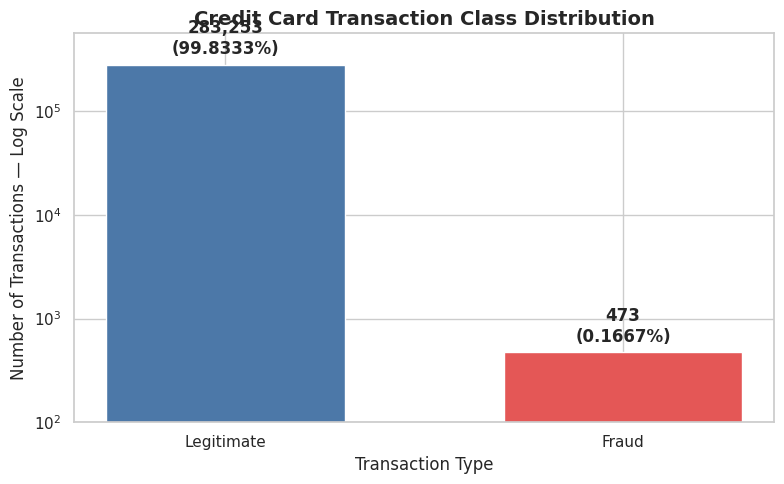

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = ["#4C78A8", "#E45756"]

bars = ax.bar(
    class_summary["Transaction_Type"],
    class_summary["Transaction_Count"],
    color=colors,
    width=0.6
)

# Logarithmic scale allows both classes to remain visible
ax.set_yscale("log")

for bar, (_, row) in zip(bars, class_summary.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.15,
        f"{row['Transaction_Count']:,}\n({row['Percentage']:.4f}%)",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.set_title(
    "Credit Card Transaction Class Distribution",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Transaction Type")
ax.set_ylabel("Number of Transactions — Log Scale")
ax.set_ylim(100, class_summary["Transaction_Count"].max() * 2)

plt.tight_layout()
plt.savefig(
    "fraud_class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Observation: Why Accuracy Is Misleading

The dataset is extremely imbalanced because fraudulent transactions represent only a very small percentage of all observations.

A model that predicts every transaction as legitimate could achieve an accuracy above 99%, while detecting none of the actual fraud cases. Therefore, high accuracy would not necessarily indicate a useful fraud-detection system.

The modelling stage will consequently focus on:

- **Recall:** the proportion of actual fraud cases detected
- **Precision:** the proportion of fraud alerts that are truly fraudulent
- **F1-score:** the balance between precision and recall
- **ROC-AUC:** the model's ability to distinguish between the two classes
- **Precision-Recall AUC:** performance specifically focused on the rare fraud class

## 3. Transaction Amount Analysis

Transaction amounts are compared between legitimate and fraudulent transactions to determine whether fraudulent activity displays a different financial pattern.

Mean, median, quartiles and maximum values are examined because transaction amounts are strongly skewed and may contain unusually large values.

In [7]:
amount_summary = (
    df.groupby("Class")
    .agg(
        Transaction_Count=("Amount", "count"),
        Mean_Amount=("Amount", "mean"),
        Median_Amount=("Amount", "median"),
        Standard_Deviation=("Amount", "std"),
        Minimum_Amount=("Amount", "min"),
        Q1=("Amount", lambda values: values.quantile(0.25)),
        Q3=("Amount", lambda values: values.quantile(0.75)),
        Maximum_Amount=("Amount", "max")
    )
    .reset_index()
)

amount_summary["Transaction_Type"] = amount_summary["Class"].map({
    0: "Legitimate",
    1: "Fraud"
})

amount_summary = amount_summary[
    [
        "Class",
        "Transaction_Type",
        "Transaction_Count",
        "Mean_Amount",
        "Median_Amount",
        "Standard_Deviation",
        "Minimum_Amount",
        "Q1",
        "Q3",
        "Maximum_Amount"
    ]
]

numeric_columns = amount_summary.select_dtypes(include=np.number).columns
amount_summary[numeric_columns] = amount_summary[numeric_columns].round(2)

display(amount_summary)

,Class,Transaction_Type,Transaction_Count,Mean_Amount,Median_Amount,Standard_Deviation,Minimum_Amount,Q1,Q3,Maximum_Amount
0,0,Legitimate,283253,88.4100,22.0000,250.3800,0.0000,5.6700,77.4600,"25,691.1600"
1,1,Fraud,473,123.8700,9.8200,260.2100,0.0000,1.0000,105.8900,"2,125.8700"


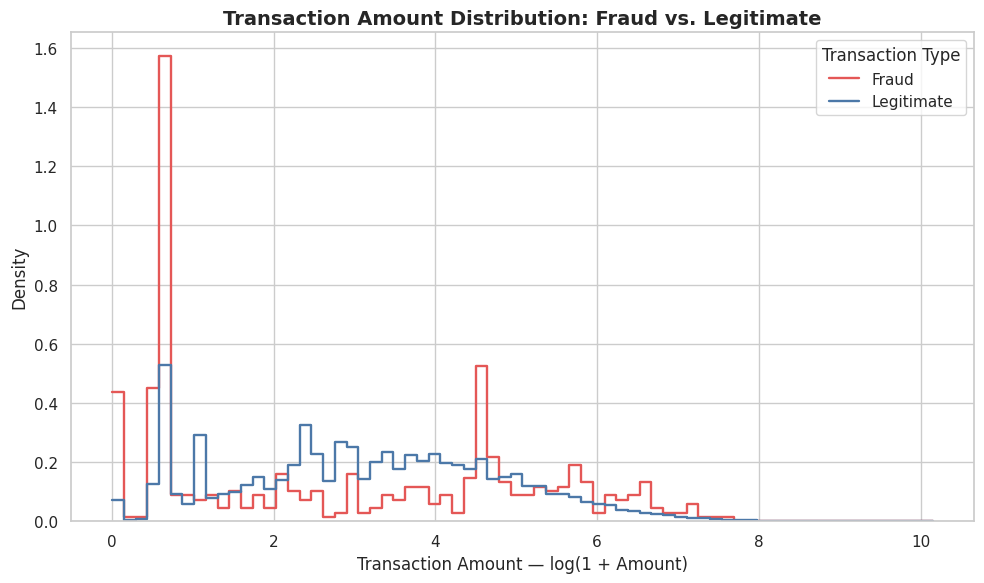

In [8]:
amount_plot_data = df[["Class", "Amount"]].copy()

amount_plot_data["Transaction_Type"] = amount_plot_data["Class"].map({
    0: "Legitimate",
    1: "Fraud"
})

# Log transformation is used only for clearer visualisation
amount_plot_data["Log_Amount"] = np.log1p(
    amount_plot_data["Amount"]
)

plt.figure(figsize=(10, 6))

sns.histplot(
    data=amount_plot_data,
    x="Log_Amount",
    hue="Transaction_Type",
    bins=70,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    linewidth=1.7,
    palette={
        "Legitimate": "#4C78A8",
        "Fraud": "#E45756"
    }
)

plt.title(
    "Transaction Amount Distribution: Fraud vs. Legitimate",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Transaction Amount — log(1 + Amount)")
plt.ylabel("Density")
plt.legend(
    title="Transaction Type",
    labels=["Fraud", "Legitimate"]
)

plt.tight_layout()
plt.savefig(
    "transaction_amount_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 4. Transaction Time Analysis

The dataset does not provide calendar timestamps. Instead, `Time` represents the number of seconds elapsed since the first recorded transaction.

A relative hour from 0 to 23 is derived to examine recurring transaction and fraud patterns during each 24-hour cycle. These values should therefore be interpreted as relative hours rather than confirmed local clock times.

In [9]:
hourly_data = df[["Time", "Class"]].copy()

# Convert elapsed seconds into a repeating 24-hour cycle
hourly_data["Relative_Hour"] = (
    (hourly_data["Time"] // 3600) % 24
).astype(int)

hourly_summary = (
    hourly_data.groupby("Relative_Hour")
    .agg(
        Total_Transactions=("Class", "count"),
        Fraud_Transactions=("Class", "sum")
    )
    .reset_index()
)

hourly_summary["Legitimate_Transactions"] = (
    hourly_summary["Total_Transactions"]
    - hourly_summary["Fraud_Transactions"]
)

hourly_summary["Fraud_Rate_Percentage"] = (
    hourly_summary["Fraud_Transactions"]
    / hourly_summary["Total_Transactions"]
    * 100
).round(4)

display(hourly_summary)

,Relative_Hour,Total_Transactions,Fraud_Transactions,Legitimate_Transactions,Fraud_Rate_Percentage
0,0,7647,6,7641,0.0785
1,1,4208,10,4198,0.2376
2,2,3308,48,3260,1.4510
3,3,3487,17,3470,0.4875
4,4,2204,23,2181,1.0436
5,5,2988,11,2977,0.3681
6,6,4082,9,4073,0.2205
7,7,7233,23,7210,0.3180
8,8,10232,9,10223,0.0880
9,9,15767,16,15751,0.1015


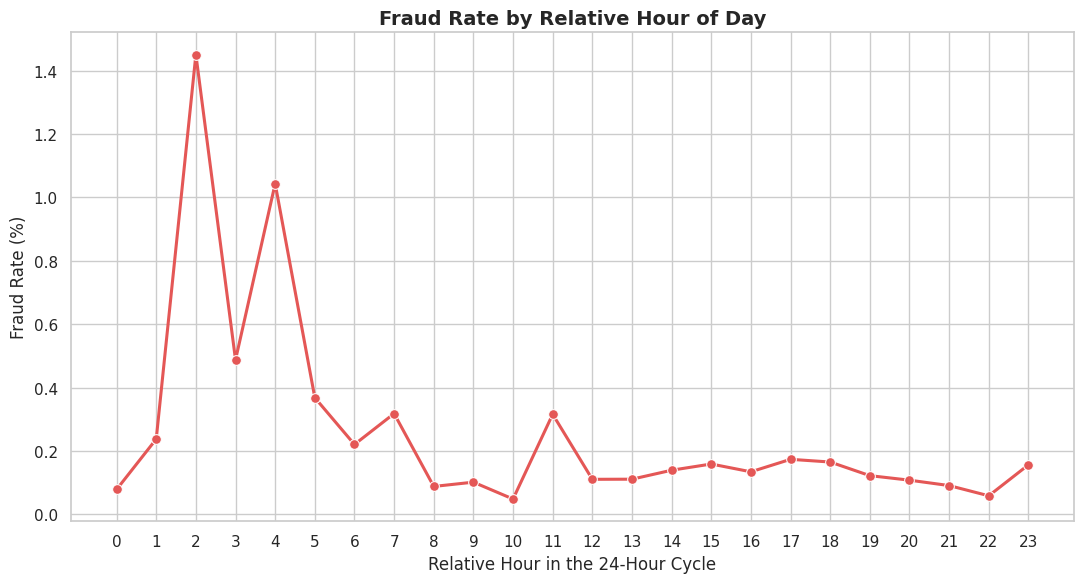

Five relative hours with the highest observed fraud rates:


,Relative_Hour,Total_Transactions,Fraud_Transactions,Fraud_Rate_Percentage
2,2,3308,48,1.4510
4,4,2204,23,1.0436
3,3,3487,17,0.4875
5,5,2988,11,0.3681
7,7,7233,23,0.3180


In [10]:
plt.figure(figsize=(11, 6))

sns.lineplot(
    data=hourly_summary,
    x="Relative_Hour",
    y="Fraud_Rate_Percentage",
    marker="o",
    linewidth=2.2,
    markersize=7,
    color="#E45756"
)

plt.title(
    "Fraud Rate by Relative Hour of Day",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Relative Hour in the 24-Hour Cycle")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))

plt.tight_layout()
plt.savefig(
    "fraud_rate_by_relative_hour.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

highest_risk_hours = hourly_summary.nlargest(
    5,
    "Fraud_Rate_Percentage"
)[
    [
        "Relative_Hour",
        "Total_Transactions",
        "Fraud_Transactions",
        "Fraud_Rate_Percentage"
    ]
]

print("Five relative hours with the highest observed fraud rates:")
display(highest_risk_hours)

## 5. Data Preparation for Machine Learning

The `Class` column is the prediction target:

- `0`: Legitimate transaction
- `1`: Fraudulent transaction

All remaining numerical columns are used as predictor features. The data is divided into 80% training and 20% testing sets.

Stratification is applied to preserve approximately the same fraud percentage in both sets. This is essential because fraud cases are extremely rare.

In [11]:
# Separate predictor features from the target
X = df.drop(columns="Class").copy()
y = df["Class"].copy()

# Stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

split_summary = pd.DataFrame({
    "Dataset": ["Training Set", "Testing Set"],
    "Total_Transactions": [len(y_train), len(y_test)],
    "Legitimate_Transactions": [
        int((y_train == 0).sum()),
        int((y_test == 0).sum())
    ],
    "Fraud_Transactions": [
        int((y_train == 1).sum()),
        int((y_test == 1).sum())
    ],
    "Fraud_Percentage": [
        y_train.mean() * 100,
        y_test.mean() * 100
    ]
})

split_summary["Fraud_Percentage"] = (
    split_summary["Fraud_Percentage"].round(4)
)

display(split_summary)

print(f"Training feature shape: {X_train.shape}")
print(f"Testing feature shape: {X_test.shape}")

,Dataset,Total_Transactions,Legitimate_Transactions,Fraud_Transactions,Fraud_Percentage
0,Training Set,226980,226602,378,0.1665
1,Testing Set,56746,56651,95,0.1674


Training feature shape: (226980, 30)
Testing feature shape: (56746, 30)


### Feature Scaling

The anonymized features `V1` through `V28` have already been numerically transformed in the original dataset. However, `Time` and `Amount` use different numerical scales.

`RobustScaler` is applied to these two features because it uses the median and interquartile range, making it less sensitive to unusually large transaction amounts.

The scaler is fitted only on the training data to prevent data leakage.

In [12]:
# Create independent copies
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

features_to_scale = ["Time", "Amount"]

scaler = RobustScaler()

# Learn scaling values only from training data
X_train_scaled[features_to_scale] = scaler.fit_transform(
    X_train[features_to_scale]
)

# Apply the learned transformation to testing data
X_test_scaled[features_to_scale] = scaler.transform(
    X_test[features_to_scale]
)

print("Feature scaling completed.")
print(f"Missing training values: {X_train_scaled.isna().sum().sum()}")
print(f"Missing testing values: {X_test_scaled.isna().sum().sum()}")

display(
    X_train_scaled[features_to_scale]
    .describe()
    .T
    .round(3)
)

Feature scaling completed.
Missing training values: 0
Missing testing values: 0


,count,mean,std,min,25%,50%,75%,max
Time,"226,980.0000",0.1180,0.5580,-0.9960,-0.3590,0.0000,0.6410,1.0340
Amount,"226,980.0000",0.9190,3.4060,-0.3060,-0.2270,0.0000,0.7730,272.0960


## 6. Class-Imbalance Handling

Balanced class weights are used to address the severe imbalance between legitimate and fraudulent transactions.

With this strategy, errors involving the minority fraud class receive a larger penalty during training. This encourages the models to pay more attention to fraudulent transactions rather than predicting almost every transaction as legitimate.

Class weighting was selected instead of generating synthetic transactions because it:

- Retains all original observations
- Does not create artificial financial records
- Requires less memory than oversampling
- Can be applied directly to both selected classifiers

This technique is explicitly accepted as an imbalance-handling method in the project requirements.

### Model 1: Logistic Regression

Logistic Regression provides an interpretable baseline for binary classification. It estimates the probability that a transaction belongs to the fraud class.

Balanced class weights are used so the rare fraud class receives greater importance during training.

In [13]:
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=RANDOM_STATE
)

print("Training Logistic Regression...")

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression training completed.")

Training Logistic Regression...
Logistic Regression training completed.


### Model 2: Random Forest

Random Forest combines multiple decision trees and can identify non-linear relationships between transaction characteristics.

The model uses balanced class weights to account for the rare fraud class. Tree depth is controlled to reduce overfitting and keep the model computationally practical.

In [18]:
random_forest_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Training Random Forest...")

random_forest_model.fit(
    X_train_scaled,
    y_train
)

print("Random Forest training completed.")

Training Random Forest...
Random Forest training completed.


In [19]:
# Predicted classes
logistic_predictions = logistic_model.predict(X_test_scaled)
random_forest_predictions = random_forest_model.predict(X_test_scaled)

# Fraud probabilities
logistic_probabilities = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

random_forest_probabilities = random_forest_model.predict_proba(
    X_test_scaled
)[:, 1]

print("Predictions generated successfully.")
print(f"Logistic Regression fraud alerts: {logistic_predictions.sum():,}")
print(f"Random Forest fraud alerts: {random_forest_predictions.sum():,}")
print(f"Actual fraud cases in testing data: {y_test.sum():,}")

Predictions generated successfully.
Logistic Regression fraud alerts: 1,476
Random Forest fraud alerts: 78
Actual fraud cases in testing data: 95


## 7. Model Evaluation

Because fraud cases are extremely rare, model selection cannot depend on accuracy alone.

The primary evaluation metrics are:

- **Precision:** Of all transactions flagged as fraud, how many were actually fraudulent?
- **Recall:** Of all actual fraudulent transactions, how many did the model detect?
- **F1-score:** The balance between precision and recall.
- **ROC-AUC:** How effectively the model separates fraudulent and legitimate transactions across different thresholds.
- **Average Precision:** Summarises the Precision-Recall curve and is particularly useful for rare-event classification.

In fraud detection, recall is especially important because a false negative represents fraud that the model failed to detect. However, precision must also be considered because excessive false alerts can increase investigation costs and inconvenience legitimate customers.

In [20]:
def evaluate_fraud_model(
    model_name,
    actual_values,
    predicted_values,
    predicted_probabilities
):
    tn, fp, fn, tp = confusion_matrix(
        actual_values,
        predicted_values
    ).ravel()

    return {
        "Model": model_name,
        "Accuracy": (predicted_values == actual_values).mean(),
        "Precision": precision_score(
            actual_values,
            predicted_values,
            zero_division=0
        ),
        "Recall": recall_score(
            actual_values,
            predicted_values,
            zero_division=0
        ),
        "F1_Score": f1_score(
            actual_values,
            predicted_values,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            actual_values,
            predicted_probabilities
        ),
        "Average_Precision": average_precision_score(
            actual_values,
            predicted_probabilities
        ),
        "Fraud_Detected_TP": tp,
        "Fraud_Missed_FN": fn,
        "False_Alerts_FP": fp,
        "Correct_Legitimate_TN": tn
    }


model_comparison = pd.DataFrame([
    evaluate_fraud_model(
        "Logistic Regression",
        y_test,
        logistic_predictions,
        logistic_probabilities
    ),
    evaluate_fraud_model(
        "Random Forest",
        y_test,
        random_forest_predictions,
        random_forest_probabilities
    )
])

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "ROC_AUC",
    "Average_Precision"
]

model_comparison[metric_columns] = (
    model_comparison[metric_columns].round(4)
)

display(model_comparison)

# Save the comparison table
model_comparison.to_csv(
    "model_comparison.csv",
    index=False
)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Average_Precision,Fraud_Detected_TP,Fraud_Missed_FN,False_Alerts_FP,Correct_Legitimate_TN
0,Logistic Regression,0.9752,0.0562,0.8737,0.1057,0.9657,0.6719,83,12,1393,55258
1,Random Forest,0.9994,0.8846,0.7263,0.7977,0.9681,0.8057,69,26,9,56642


In [21]:
logistic_report = pd.DataFrame(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=["Legitimate", "Fraud"],
        output_dict=True,
        zero_division=0
    )
).T.round(4)

random_forest_report = pd.DataFrame(
    classification_report(
        y_test,
        random_forest_predictions,
        target_names=["Legitimate", "Fraud"],
        output_dict=True,
        zero_division=0
    )
).T.round(4)

print("Logistic Regression Classification Report")
display(logistic_report)

print("\nRandom Forest Classification Report")
display(random_forest_report)

Logistic Regression Classification Report


,precision,recall,f1-score,support
Legitimate,0.9998,0.9754,0.9874,"56,651.0000"
Fraud,0.0562,0.8737,0.1057,95.0000
accuracy,0.9752,0.9752,0.9752,0.9752
macro avg,0.5280,0.9245,0.5466,"56,746.0000"
weighted avg,0.9982,0.9752,0.9860,"56,746.0000"



Random Forest Classification Report


,precision,recall,f1-score,support
Legitimate,0.9995,0.9998,0.9997,"56,651.0000"
Fraud,0.8846,0.7263,0.7977,95.0000
accuracy,0.9994,0.9994,0.9994,0.9994
macro avg,0.9421,0.8631,0.8987,"56,746.0000"
weighted avg,0.9993,0.9994,0.9994,"56,746.0000"


In [22]:
def plot_fraud_confusion_matrix(
    actual_values,
    predicted_values,
    model_name,
    filename
):
    matrix = confusion_matrix(
        actual_values,
        predicted_values
    )

    plt.figure(figsize=(7, 5))

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Legitimate", "Fraud"],
        yticklabels=["Legitimate", "Fraud"]
    )

    plt.title(
        f"{model_name} Confusion Matrix",
        fontsize=14,
        fontweight="bold"
    )
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.tight_layout()
    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

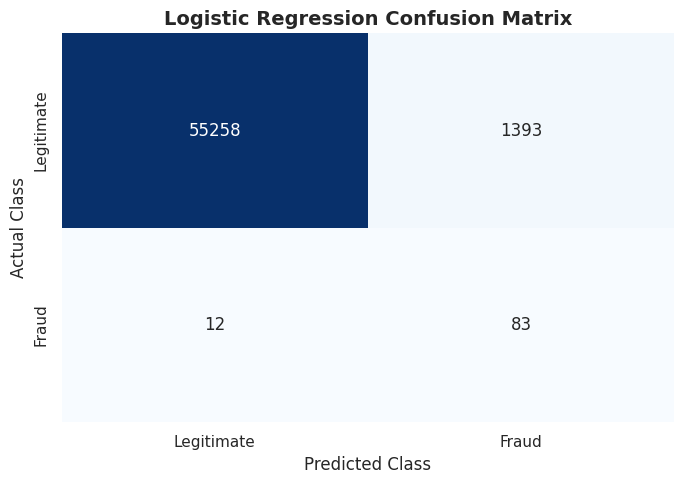

In [23]:
plot_fraud_confusion_matrix(
    y_test,
    logistic_predictions,
    "Logistic Regression",
    "logistic_regression_confusion_matrix.png"
)

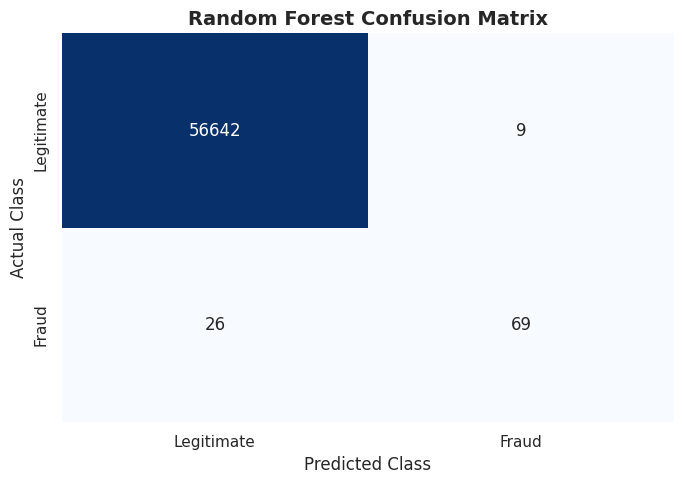

In [24]:
plot_fraud_confusion_matrix(
    y_test,
    random_forest_predictions,
    "Random Forest",
    "random_forest_confusion_matrix.png"
)

### ROC Curve

The ROC curve compares the true-positive rate against the false-positive rate across different classification thresholds.

A model closer to the upper-left corner and with a larger ROC-AUC value has stronger overall class-separation ability.

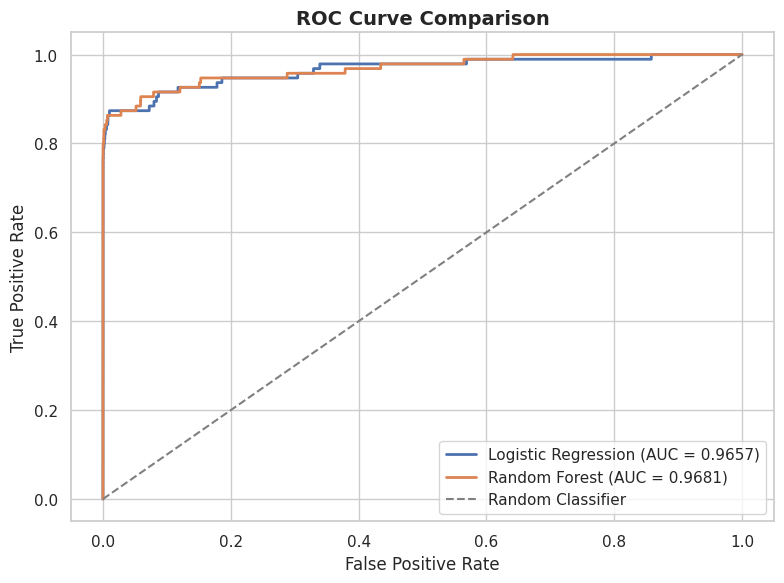

In [25]:
logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_probabilities
)

forest_fpr, forest_tpr, _ = roc_curve(
    y_test,
    random_forest_probabilities
)

logistic_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

forest_auc = roc_auc_score(
    y_test,
    random_forest_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    linewidth=2,
    label=f"Logistic Regression (AUC = {logistic_auc:.4f})"
)

plt.plot(
    forest_fpr,
    forest_tpr,
    linewidth=2,
    label=f"Random Forest (AUC = {forest_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey",
    label="Random Classifier"
)

plt.title(
    "ROC Curve Comparison",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

plt.tight_layout()
plt.savefig(
    "roc_curve_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Precision-Recall Curve

The Precision-Recall curve focuses directly on performance for the positive fraud class. It is particularly useful for this dataset because the number of fraudulent transactions is extremely small compared with legitimate transactions.

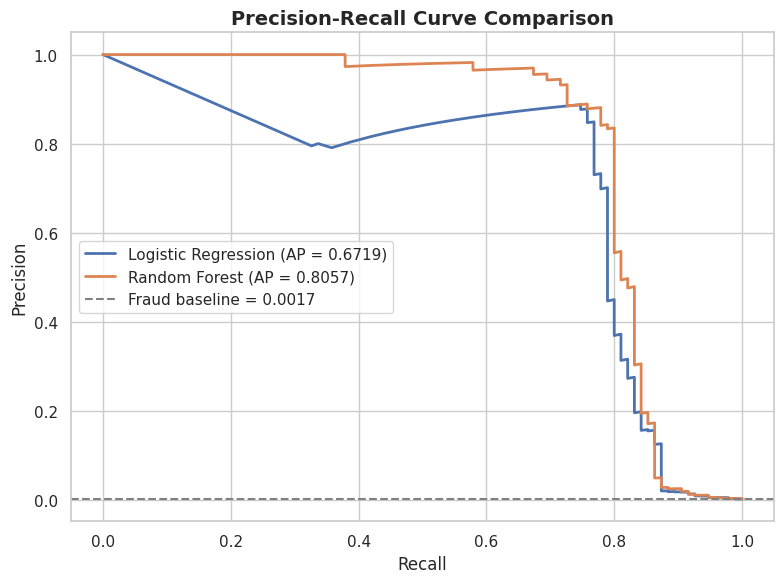

In [26]:
logistic_precision, logistic_recall, _ = precision_recall_curve(
    y_test,
    logistic_probabilities
)

forest_precision, forest_recall, _ = precision_recall_curve(
    y_test,
    random_forest_probabilities
)

logistic_ap = average_precision_score(
    y_test,
    logistic_probabilities
)

forest_ap = average_precision_score(
    y_test,
    random_forest_probabilities
)

fraud_baseline = y_test.mean()

plt.figure(figsize=(8, 6))

plt.plot(
    logistic_recall,
    logistic_precision,
    linewidth=2,
    label=f"Logistic Regression (AP = {logistic_ap:.4f})"
)

plt.plot(
    forest_recall,
    forest_precision,
    linewidth=2,
    label=f"Random Forest (AP = {forest_ap:.4f})"
)

plt.axhline(
    fraud_baseline,
    linestyle="--",
    color="grey",
    label=f"Fraud baseline = {fraud_baseline:.4f}"
)

plt.title(
    "Precision-Recall Curve Comparison",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="best")

plt.tight_layout()
plt.savefig(
    "precision_recall_curve_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Model Evaluation Findings

Logistic Regression achieved a fraud recall of **87.37%**, detecting approximately 83 of the 95 fraudulent transactions in the testing set. However, its fraud precision was only **5.62%**, producing a large number of false fraud alerts. Its fraud F1-score was consequently only **10.57%**.

Random Forest detected **69 of the 95 fraudulent transactions**, producing a recall of **72.63%**. Although its recall was lower than Logistic Regression, it achieved **88.46% precision** and a substantially stronger **79.77% F1-score**. It generated only **9 false alerts**, while missing 26 fraud cases.

The ROC-AUC scores were similar:

- Logistic Regression: **0.9657**
- Random Forest: **0.9681**

However, Random Forest produced a considerably stronger Average Precision score:

- Logistic Regression: **0.6719**
- Random Forest: **0.8057**

Random Forest is therefore selected as the better overall model because it provides a more practical balance between identifying fraud and limiting false alerts.

Logistic Regression may be preferred when detecting the maximum possible number of fraud cases is the only priority. However, its very low precision would create a substantial operational burden because many legitimate transactions would require unnecessary investigation.

## 8. Feature Importance Analysis

Random Forest feature importance measures how much each variable contributed to the model's classification decisions.

Because features `V1` through `V28` were anonymized in the original dataset, their business meanings are unavailable. They can still be ranked according to their predictive importance, but they should not be assigned unsupported real-world interpretations.

In [27]:
feature_importance = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance["Importance_Percentage"] = (
    feature_importance["Importance"] * 100
)

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Top 15 Random Forest features:")
display(feature_importance.head(15).round(4))

feature_importance.to_csv(
    "random_forest_feature_importance.csv",
    index=False
)

Top 15 Random Forest features:


,Feature,Importance,Importance_Percentage
0,V14,0.1880,18.8034
1,V10,0.1364,13.6414
2,V12,0.1158,11.5829
3,V4,0.1046,10.4589
4,V17,0.0813,8.1259
5,V3,0.0562,5.6166
6,V16,0.0494,4.9431
7,V11,0.0424,4.2357
8,V2,0.0306,3.0577
9,V7,0.0254,2.5382


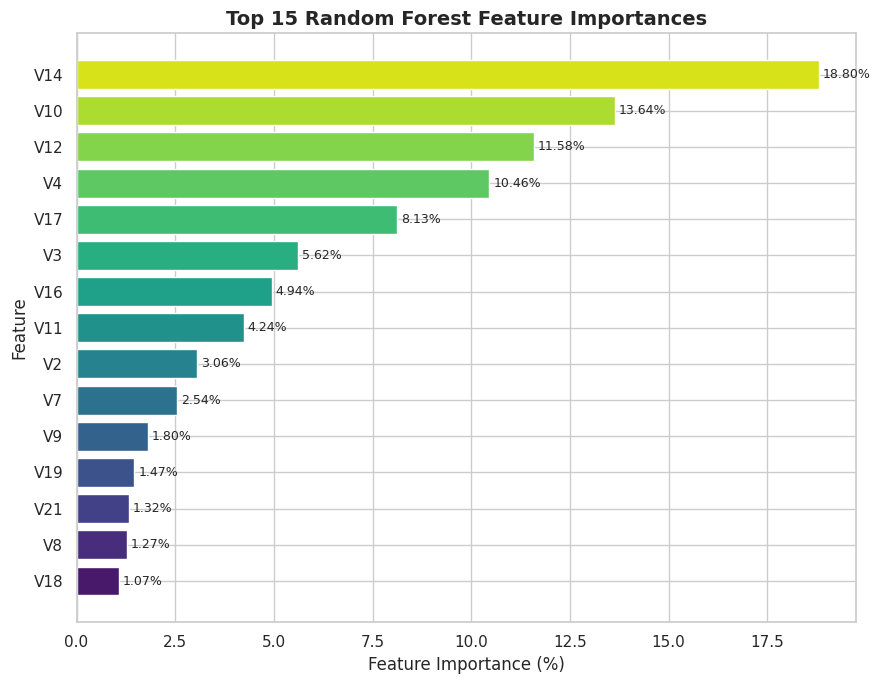

In [28]:
top_features = (
    feature_importance
    .head(15)
    .sort_values("Importance_Percentage")
)

plt.figure(figsize=(9, 7))

bars = plt.barh(
    top_features["Feature"],
    top_features["Importance_Percentage"],
    color=sns.color_palette(
        "viridis",
        len(top_features)
    )
)

for bar, value in zip(
    bars,
    top_features["Importance_Percentage"]
):
    plt.text(
        value + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center",
        fontsize=9
    )

plt.title(
    "Top 15 Random Forest Feature Importances",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Feature Importance (%)")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig(
    "random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Feature-Importance Observation

The Random Forest model relies more heavily on a limited group of anonymized transaction characteristics, while several other features make comparatively small contributions.

This indicates that fraudulent behaviour is not distributed equally across all available variables. However, because the `V1`–`V28` features are anonymized transformations, their importance can identify useful predictive signals but cannot explain the original financial behaviour represented by each feature.

Feature importance also represents association with the model's predictions rather than proof that a feature causes fraudulent activity.

## 9. Precision and Recall Trade-Off

Recall is particularly important in fraud detection because a false negative represents a fraudulent transaction that the system failed to identify. Missed fraud may result in financial loss, customer harm and additional recovery costs.

However, maximizing recall without considering precision can produce an excessive number of false alerts. These alerts increase investigation costs and may cause legitimate customers to experience unnecessary transaction delays or account restrictions.

For this project, F1-score and Average Precision provide the most useful overall comparison because they evaluate the balance between fraud detection and alert reliability.

Random Forest provides the stronger operational balance. In a real system, its probability threshold could be adjusted according to business costs:

- A lower threshold would increase recall but create more false alerts.
- A higher threshold would increase precision but miss more fraud.
- Medium-risk transactions could require additional authentication rather than being automatically rejected.

## 10. Scalability: Processing One Million Transactions per Hour

One million transactions per hour corresponds to approximately 278 transactions per second on average. A production system would also need to support significantly larger short-term traffic peaks.

A scalable implementation should include:

1. **Streaming ingestion:** Transactions should enter through a distributed event-streaming platform such as Apache Kafka rather than being loaded from a CSV file.

2. **Reusable preprocessing:** The fitted scaler and required feature transformations should be saved and applied consistently to every incoming transaction.

3. **Real-time prediction service:** The trained model should be deployed behind a low-latency API or streaming inference service.

4. **Horizontal scaling:** Multiple prediction-service instances should process transactions in parallel behind a load balancer.

5. **Risk-based decisions:** High-risk transactions could be blocked or sent for immediate investigation, while medium-risk transactions could trigger additional authentication.

6. **Monitoring:** Precision, recall, false-alert rate, latency and changes in the incoming data distribution should be monitored continuously.

7. **Model retraining:** Fraud strategies change over time. The model should be periodically retrained using newly verified transactions.

8. **Human review:** The model should support fraud investigators rather than acting as the sole basis for irreversible financial decisions.

Before deployment, the complete pipeline would need load testing to confirm that preprocessing and prediction remain within the required latency at both normal and peak traffic levels.

# Conclusion and Recommendations

This project developed a complete machine learning pipeline for detecting fraudulent credit card transactions in a severely imbalanced dataset.

The analysis showed that fraudulent transactions form only a very small proportion of all observations. Consequently, accuracy alone was unsuitable for model evaluation because a model could achieve very high accuracy while failing to detect fraud.

Two classification models were trained using balanced class weights:

- Logistic Regression
- Random Forest

Logistic Regression achieved the higher fraud recall of **87.37%**, but its fraud precision was only **5.62%**, resulting in many false alerts and an F1-score of **10.57%**.

Random Forest achieved **88.46% precision**, **72.63% recall**, a **79.77% F1-score**, a **0.9681 ROC-AUC**, and a **0.8057 Average Precision score**. It correctly detected 69 fraud cases while generating only 9 false alerts.

Random Forest is therefore selected as the most suitable model from this experiment because it provides the strongest balance between detecting fraudulent transactions and maintaining reliable alerts.

## Actionable Recommendations

1. **Use Random Forest as the primary fraud-screening model.**  
   Its high precision would reduce unnecessary investigations and customer inconvenience while still detecting a substantial proportion of fraud.

2. **Introduce risk-based decision thresholds.**  
   High-risk transactions should be reviewed or temporarily blocked, while medium-risk transactions could trigger an additional authentication step.

3. **Prioritize false-negative investigation.**  
   The 26 missed fraud cases should be examined to identify patterns that the current model failed to learn.

4. **Monitor model performance continuously.**  
   Fraud patterns may change over time, so recall, precision, alert volume and feature distributions should be monitored for model drift.

5. **Retrain the model using recently verified transactions.**  
   Periodic retraining would help the system adapt to new fraud strategies.

## Limitations

- The dataset contains transactions from only a short period.
- Most predictor variables are anonymized, limiting business interpretation.
- Model performance was evaluated using one stratified train/test split.
- No financial cost was assigned to false positives and false negatives.
- The selected classification threshold was not optimized for a specific business objective.
- Production latency and scalability were discussed conceptually but not load-tested.